# Seasonal Agriculture Performance Analysis

## VOIS AICTE Batch 1 2026–2027 — Major Project

### Introduction

Agricultural performance is influenced by seasonal variations in environmental
conditions, farming practices, resource availability, crop selection and market
conditions.

This project analyzes the provided agricultural dataset to understand how
agricultural performance varies across different seasons and geographical
regions. The analysis focuses on yield, profitability, resource usage,
environmental conditions, irrigation practices and disease/pest risk.

The objective is to identify meaningful patterns, relationships and differences
within the available data and develop evidence-based insights for seasonal
agricultural planning.

## Problem Statement

Raw agricultural data does not clearly explain how agricultural performance
changes across seasons or what patterns can be observed under different
seasonal conditions.

The problem is to analyze the agricultural dataset and investigate seasonal
differences in agricultural performance by identifying meaningful patterns,
trends, relationships and variations.

## Objectives

- Explore and understand the dataset.
- Clean and prepare the data for analysis.
- Examine agricultural performance across seasons.
- Compare yield, profitability and resource usage.
- Analyze environmental conditions.
- Investigate irrigation and water-use efficiency.
- Study crop-wise and regional differences.
- Identify relationships between agricultural variables.
- Apply appropriate statistical and visualization techniques.
- Develop evidence-based conclusions and recommendations.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('seasonal_agriculture_performance_dataset (3).csv')

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [18]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
display(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
display(df.dtypes)

Dataset Shape: (4000, 28)

Missing Values:


,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32



Duplicate Rows: 0

Data Types:


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [19]:
# Handle missing values using median imputation

df['Rainfall_mm'] = df['Rainfall_mm'].fillna(
    df['Rainfall_mm'].median()
)

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].median()
)

print("Missing values have been handled using median imputation.")

Missing values have been handled using median imputation.


In [20]:
print("Total Missing Values After Cleaning:",
      df.isnull().sum().sum())

print("Duplicate Rows:",
      df.duplicated().sum())

print("\nFirst 5 Records:")
display(df.head())

Total Missing Values After Cleaning: 0
Duplicate Rows: 0

First 5 Records:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [21]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nSeasons:")
display(df['Season'].value_counts())

print("\nNumber of Crops:", df['Crop'].nunique())

print("\nCrops:")
print(df['Crop'].unique())

print("\nNumber of States:", df['State'].nunique())

print("\nStatistical Summary:")
display(df.describe().round(2))

Number of Rows: 4000
Number of Columns: 28

Seasons:


,count
Season,
Kharif,1779
Rabi,1627
Zaid,594



Number of Crops: 8

Crops:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Number of States: 8

Statistical Summary:


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,...,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,600.92,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,...,0.83,5.24,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,287.19,3.82,11.96,1.12,0.64,6.68,31.22,17.02,27.74,...,0.10,13.31,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,...,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,371.58,23.90,54.78,6.60,6.26,21.80,98.50,46.20,86.20,...,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.90,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,...,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,831.98,29.60,71.90,8.10,7.14,31.20,141.22,69.40,123.60,...,0.91,2.83,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,...,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


## Analytical Questions

1. How does agricultural yield vary across seasons?
2. Which season has the highest average profit?
3. How does water usage differ across seasons?
4. Which season has the highest disease and pest risk?
5. Which crops perform best and worst economically?
6. How does irrigation method affect water-use efficiency?
7. What relationships exist between environmental conditions and yield?
8. How does agricultural performance vary across states?
9. Which crop-season combinations show better economic performance?
10. What insights can support better seasonal agricultural planning?

In [22]:
seasonal_metrics = df.groupby('Season')[
    [
        'Yield_Tonnes_Ha',
        'Profit_INR',
        'Water_Used_m3',
        'Disease_Pest_Risk_pct'
    ]
].agg(['mean', 'std']).round(2)

print("=== Seasonal Agricultural Performance ===")
display(seasonal_metrics)

=== Seasonal Agricultural Performance ===


Yield_Tonnes_Ha        Profit_INR            Water_Used_m3           \
                  mean    std       mean        std          mean      std   
Season                                                                       
Kharif            5.63  14.39  178914.65  611549.78       6102.20  5670.58   
Rabi              5.04  12.75   87689.47  489901.25       5846.99  5397.65   
Zaid              4.64  11.27  -24804.82  436356.75       6419.89  5734.62   

       Disease_Pest_Risk_pct         
                        mean    std  
Season                               
Kharif                 54.47  10.09  
Rabi                   40.48  10.10  
Zaid                   38.22   9.87

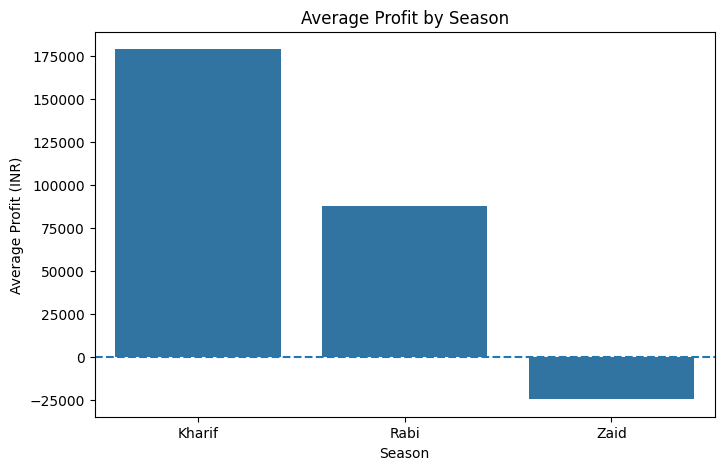

In [23]:
seasonal_summary = df.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3',
     'Disease_Pest_Risk_pct']
].mean()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=seasonal_summary.index,
    y=seasonal_summary['Profit_INR'].values,
    errorbar=None
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.axhline(0, linestyle='--')
plt.show()

=== Average Yield by Season ===


,Yield_Tonnes_Ha
Season,
Kharif,5.63
Rabi,5.04
Zaid,4.64


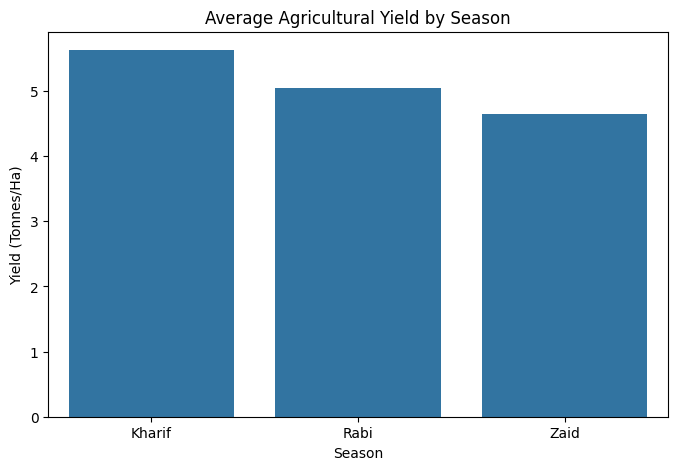

In [24]:
season_yield = df.groupby('Season')[
    'Yield_Tonnes_Ha'
].mean().sort_values(ascending=False)

print("=== Average Yield by Season ===")
display(season_yield.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values,
    errorbar=None
)

plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [25]:
crop_performance = df.groupby('Crop')[
    [
        'Yield_Tonnes_Ha',
        'Profit_INR',
        'Water_Used_m3'
    ]
].mean().sort_values(
    'Profit_INR',
    ascending=False
).round(2)

print("=== Crop-wise Agricultural Performance ===")
display(crop_performance)

=== Crop-wise Agricultural Performance ===


,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3
Crop,,,
Sugarcane,46.64,817187.99,13897.70
Chilli,1.54,750878.34,4577.47
Cotton,1.23,124546.92,5410.86
Groundnut,1.32,44858.12,3459.54
Pulses,0.92,-4238.05,2833.67
Maize,2.71,-83978.33,4377.78
Rice,2.43,-102213.50,10920.22
Wheat,2.11,-123398.34,4054.40


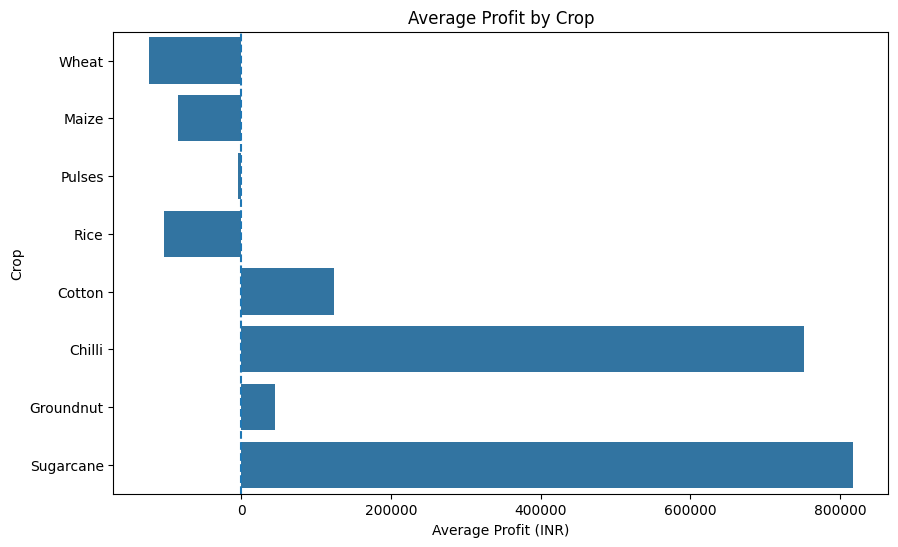

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='Profit_INR',
    y='Crop',
    estimator='mean',
    errorbar=None
)

plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')
plt.axvline(0, linestyle='--')
plt.show()

=== Zaid Season Crop Profitability ===


,Profit_INR
Crop,
Sugarcane,583635.80
Chilli,448659.09
Cotton,-53925.34
Groundnut,-68872.50
Pulses,-139227.81
Wheat,-193208.95
Maize,-194049.17
Rice,-227239.34


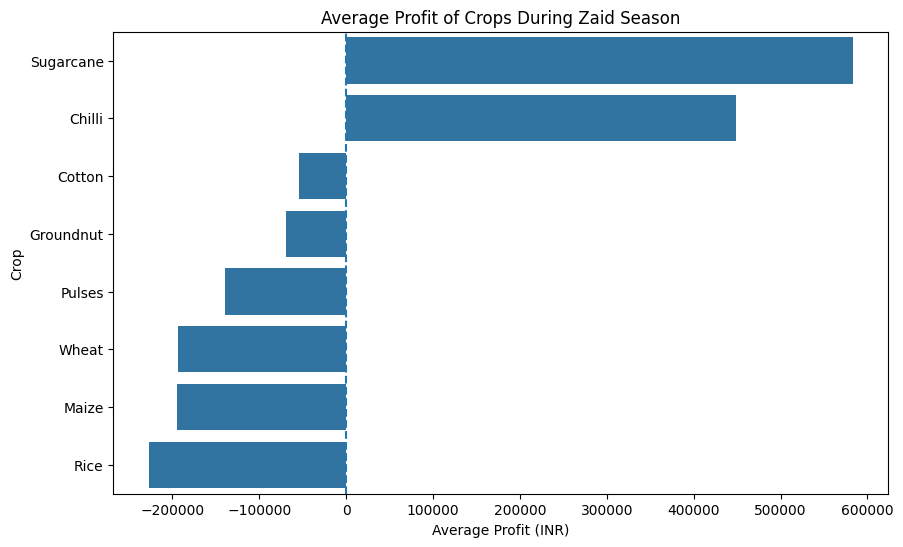

In [27]:
zaid_df = df[df['Season'] == 'Zaid']

zaid_crop_profit = zaid_df.groupby('Crop')[
    'Profit_INR'
].mean().sort_values(ascending=False)

print("=== Zaid Season Crop Profitability ===")
display(zaid_crop_profit.round(2))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=zaid_crop_profit.values,
    y=zaid_crop_profit.index,
    errorbar=None
)

plt.title('Average Profit of Crops During Zaid Season')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')
plt.axvline(0, linestyle='--')
plt.show()

In [28]:
irrigation_analysis = df.groupby(
    'Irrigation_Method'
)[
    [
        'Water_Used_m3',
        'Water_Efficiency_t_per_1000m3',
        'Yield_Tonnes_Ha',
        'Profit_INR'
    ]
].mean().sort_values(
    'Water_Efficiency_t_per_1000m3',
    ascending=False
).round(2)

print("=== Irrigation Method Performance ===")
display(irrigation_analysis)

=== Irrigation Method Performance ===


,Water_Used_m3,Water_Efficiency_t_per_1000m3,Yield_Tonnes_Ha,Profit_INR
Irrigation_Method,,,,
Rainfed,3549.55,7.56,4.60,79050.37
Drip,5918.75,6.27,6.58,219626.00
Sprinkler,6208.26,4.67,5.16,91121.08
Flood,8026.47,3.44,4.86,73354.02


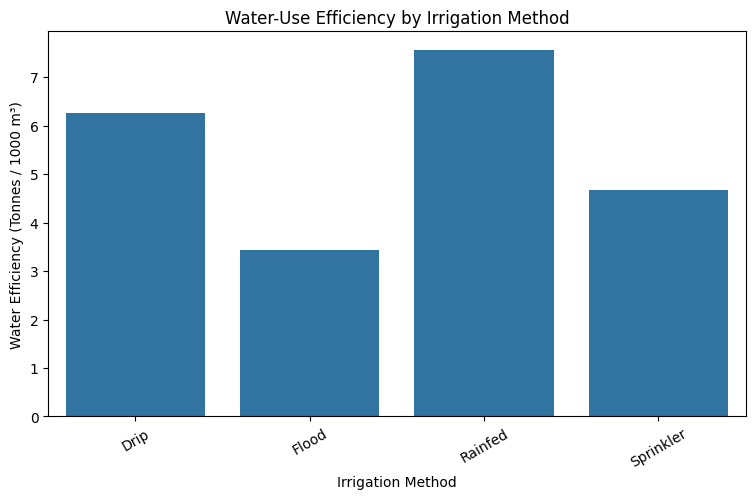

In [29]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x='Irrigation_Method',
    y='Water_Efficiency_t_per_1000m3',
    errorbar=None
)

plt.title('Water-Use Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (Tonnes / 1000 m³)')
plt.xticks(rotation=30)
plt.show()

In [30]:
environmental_cols = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct'
]

environmental_summary = df.groupby(
    'Season'
)[environmental_cols].mean().round(2)

print("=== Environmental Conditions by Season ===")
display(environmental_summary)

=== Environmental Conditions by Season ===


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


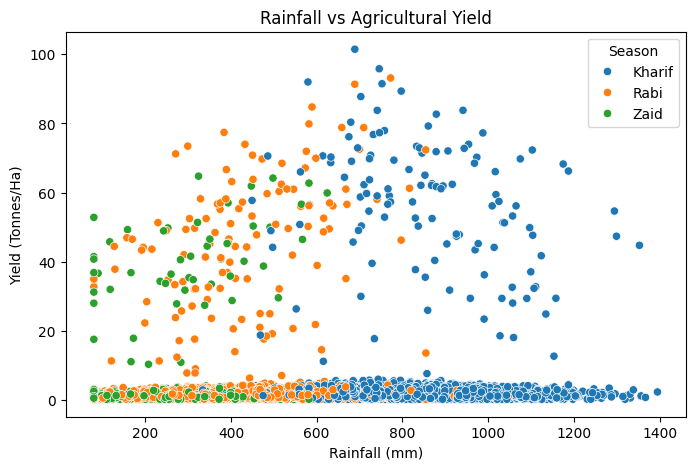

In [31]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Agricultural Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

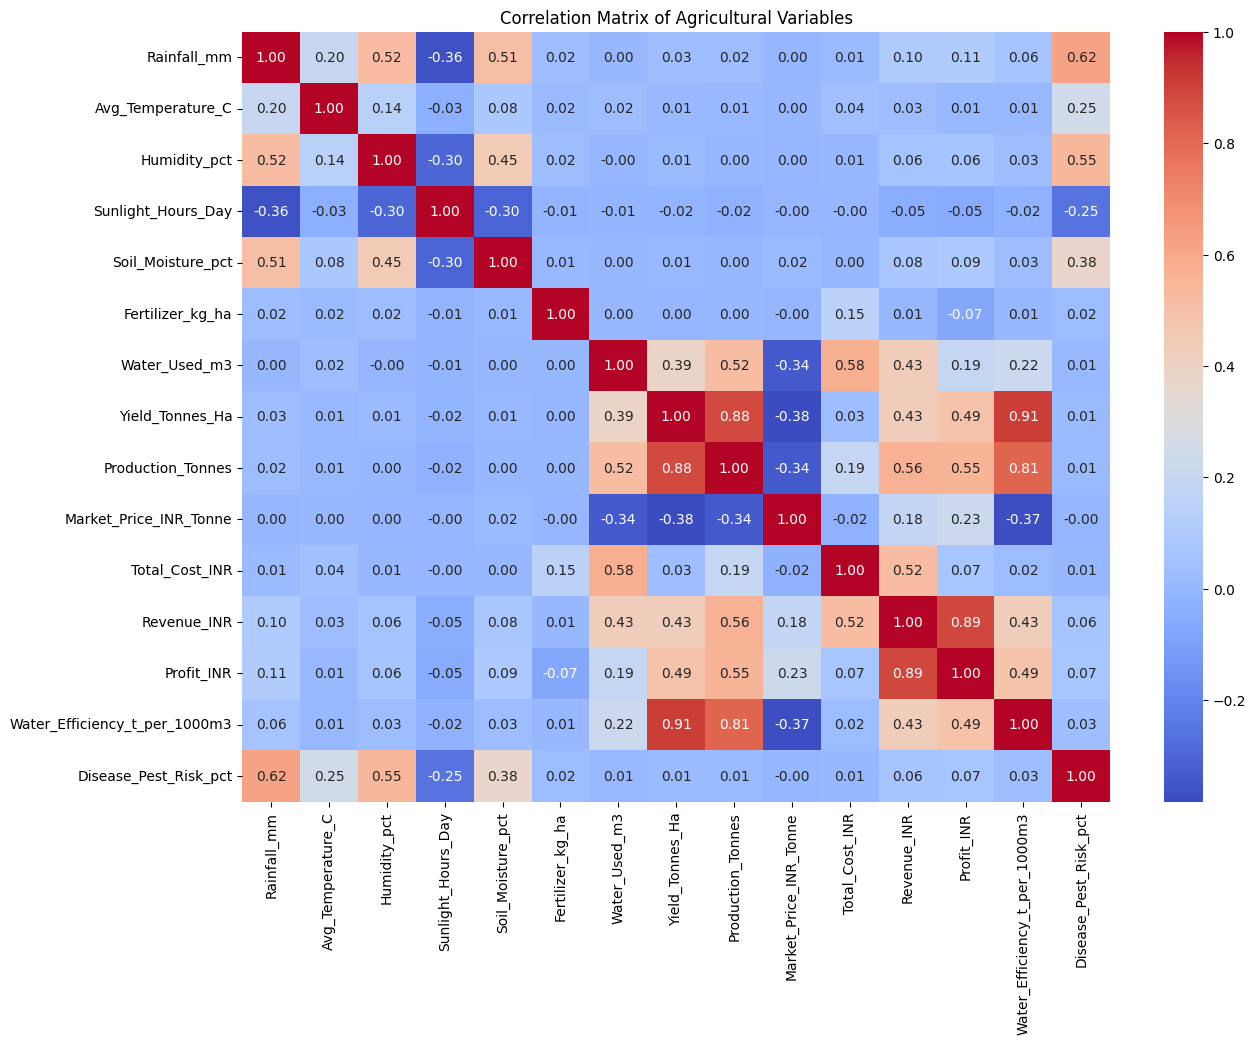

In [32]:
numeric_cols = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Water_Used_m3',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Agricultural Variables')
plt.show()

In [33]:
state_performance = df.groupby('State')[
    [
        'Yield_Tonnes_Ha',
        'Profit_INR',
        'Water_Used_m3'
    ]
].mean().sort_values(
    'Profit_INR',
    ascending=False
).round(2)

print("=== State-wise Agricultural Performance ===")
display(state_performance)

=== State-wise Agricultural Performance ===


,Yield_Tonnes_Ha,Profit_INR,Water_Used_m3
State,,,
Punjab,6.12,136025.64,6565.92
Maharashtra,5.02,135428.86,5968.08
Karnataka,5.69,119422.34,6414.33
Tamil Nadu,4.88,117744.75,5775.22
Gujarat,5.66,117568.24,6142.50
Telangana,5.04,108829.62,5801.83
Madhya Pradesh,4.99,86840.76,5663.92
Andhra Pradesh,4.63,73453.53,6058.38


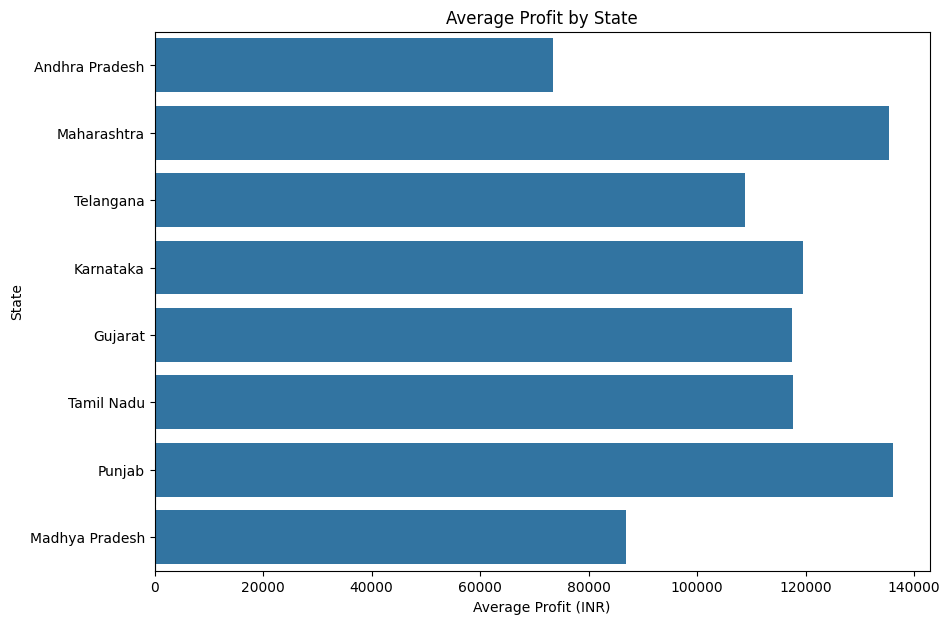

In [34]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=df,
    x='Profit_INR',
    y='State',
    estimator='mean',
    errorbar=None
)

plt.title('Average Profit by State')
plt.xlabel('Average Profit (INR)')
plt.ylabel('State')
plt.axvline(0, linestyle='--')
plt.show()

In [35]:
economic_summary = df.groupby('Season')[
    [
        'Total_Cost_INR',
        'Revenue_INR',
        'Profit_INR'
    ]
].mean().round(2)

print("=== Economic Performance by Season ===")
display(economic_summary)

=== Economic Performance by Season ===


,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.41,710719.06,178914.65
Rabi,513836.58,601526.05,87689.47
Zaid,543976.73,519171.90,-24804.82


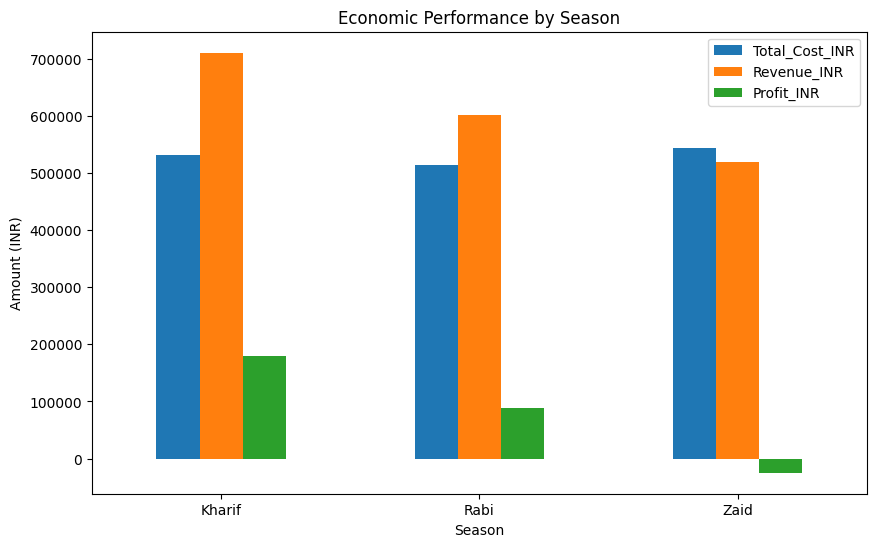

In [36]:
economic_plot = df.groupby('Season')[
    [
        'Total_Cost_INR',
        'Revenue_INR',
        'Profit_INR'
    ]
].mean()

economic_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Economic Performance by Season')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.show()

# Key Findings

Based on the analysis of the agricultural dataset:

- Agricultural yield varies across the three seasons.
- Kharif shows strong agricultural and economic performance in the available dataset.
- Zaid records comparatively lower average yield and profitability.
- Water consumption differs across seasons.
- Disease and pest risk varies by season.
- Crop profitability shows substantial variation between crops.
- Irrigation methods differ in terms of water-use efficiency.
- Environmental variables such as rainfall, temperature, humidity and soil moisture show relationships with agricultural outcomes.
- Agricultural performance also varies across states.
- Economic outcomes are influenced by differences in production costs, revenue and market conditions.

All conclusions are based on patterns observed in the available dataset.

# Evidence-Based Recommendations

1. **Improve seasonal crop planning**
   - Crop selection should consider seasonal environmental conditions,
     expected yield and economic performance.

2. **Improve water-use efficiency**
   - Irrigation methods with better water-use efficiency should be evaluated
     for suitable agricultural conditions.

3. **Strengthen disease and pest monitoring**
   - Seasons showing higher disease/pest risk should receive greater attention
     to crop monitoring and preventive management.

4. **Use environmental indicators**
   - Rainfall, soil moisture, temperature and humidity can be considered
     when planning seasonal agricultural activities.

5. **Consider regional differences**
   - Agricultural planning should account for differences between states
     and local farming conditions.

# Limitations

- The analysis is based only on the available dataset.
- Median imputation was used for selected missing numerical values.
- Correlation identifies relationships but does not establish causation.
- Seasonal averages may hide differences between individual farms.
- Some factors influencing agricultural performance may not be represented
  in the dataset.

# Conclusion

The Seasonal Agriculture Performance Analysis demonstrates that agricultural
performance varies across seasons in terms of yield, profitability, water
usage, environmental conditions and disease/pest risk.

The analysis shows meaningful differences between seasons and crops, while
irrigation practices and regional conditions also contribute to variations
in agricultural outcomes. Kharif demonstrates stronger overall performance
in several important indicators, whereas Zaid shows comparatively lower
yield and profitability in the available dataset.

The correlation, crop-wise, irrigation, environmental, regional and economic
analyses provide a broader understanding of the factors associated with
agricultural performance.

Overall, the findings demonstrate how data analytics can support
evidence-based seasonal agricultural planning, resource management and
identification of areas requiring further investigation.